In [ ]:
import os
import zipfile
import json
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Распаковка архива ===
zip_path = "DataGeoEPCI.zip" 
extract_path = "DataGeoEPCI_extracted"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [2]:
# === 2. Извлечение .geojson файлов ===
inner_dir = os.path.join(extract_path, 'DataGeoEPCI')
geojson_files = [f for f in os.listdir(inner_dir) if f.endswith('.geojson')]

In [3]:
# === 3. Объединение всех properties ===
all_records = []

for file in geojson_files:
    file_path = os.path.join(inner_dir, file)
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    for feature in data['features']:
        props = feature['properties']
        props['source_file'] = file
        all_records.append(props)

In [4]:
# === 4. Создание DataFrame ===
df = pd.DataFrame(all_records)

In [6]:
# === 5. Сохранение в CSV ===
df.to_csv("EPCI_metadata.csv", index=False)
print("✅ Données sauvegardées dans EPCI_metadata.csv")

✅ Données sauvegardées dans EPCI_metadata.csv


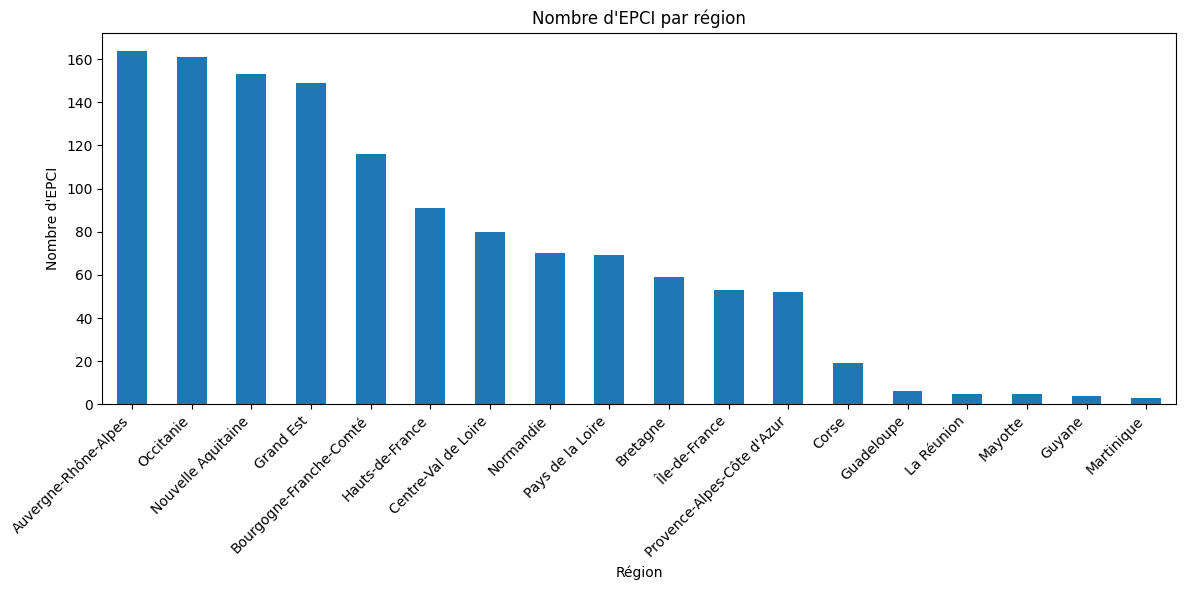

In [7]:
# === 6. Группировки и визуализации ===
df['autreNom région'].value_counts().sort_values(ascending=False).plot(
    kind='bar', figsize=(12, 6), title="Nombre d'EPCI par région"
)
plt.xlabel("Région")
plt.ylabel("Nombre d'EPCI")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

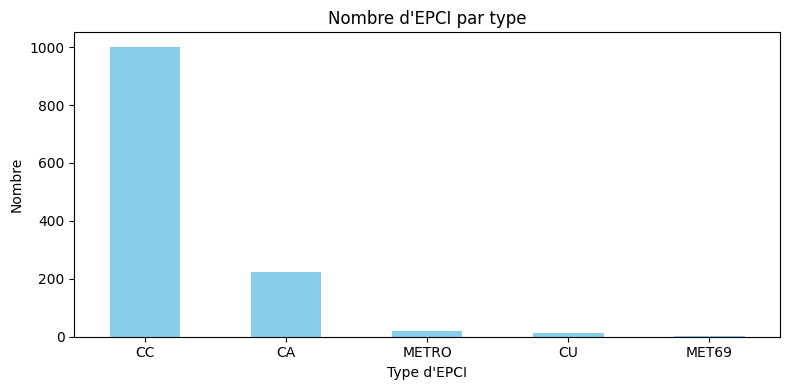

In [8]:
df['TYPE_EPCI'].value_counts().sort_values(ascending=False).plot(
    kind='bar', figsize=(8, 4), title="Nombre d'EPCI par type", color='skyblue'
)
plt.xlabel("Type d'EPCI")
plt.ylabel("Nombre")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

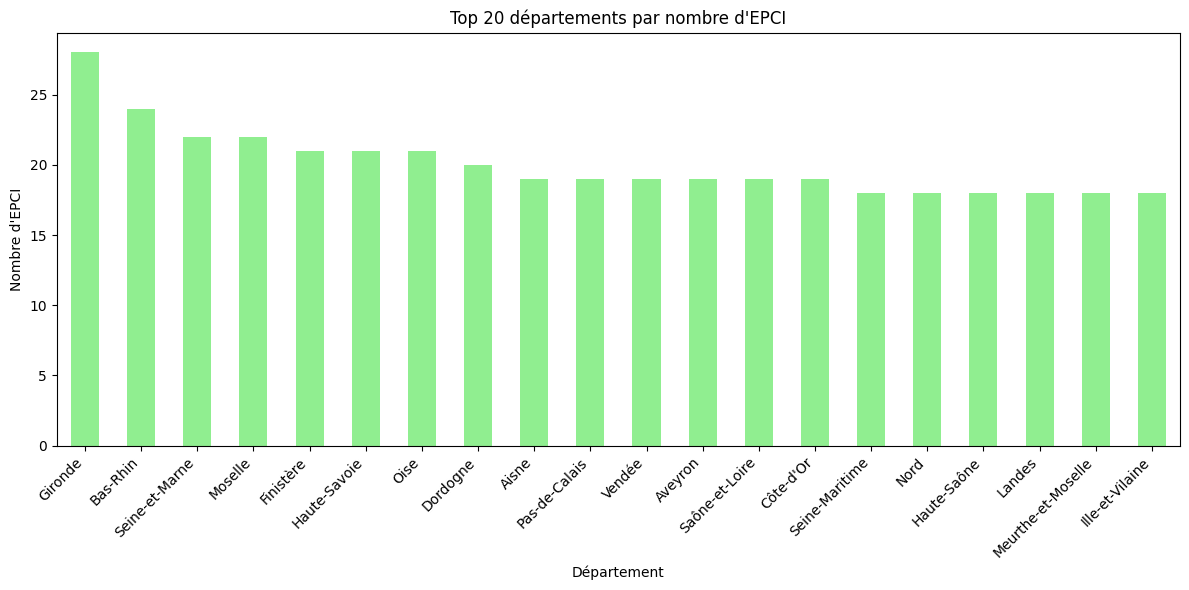

In [9]:
df['autreNom département'].value_counts().sort_values(ascending=False).head(20).plot(
    kind='bar', figsize=(12, 6), title="Top 20 départements par nombre d'EPCI", color='lightgreen'
)
plt.xlabel("Département")
plt.ylabel("Nombre d'EPCI")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()